<a href="https://colab.research.google.com/github/Aayush974/learning-pytorch/blob/main/02_ComputerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Computer vision

Computer vision is the process by which a computer seems to recognize visual information.
Common use cases include
- object detection
- image recognition
- segmentation problems

Some important pytorch computer vision libraries are

| Header 1 | Header 2 |
| -------- | -------- |
| torchvision | contains various models, datasets and transformers used in computer vision |
| torchvision.datasets | contains datasets for various computer vision problems like image recognition, object detection etc |
| torchvision.models | contains various pre trained models in pytroch|
| torchvision.transforms | various image processing tools |

In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor


# setting up the dataset

the Dataset we'll be working with is the FashionMnist dataset which is a popular datset containing greyscale images of 10 different fashion articles like boots, pullovers, shirts etc

In [ ]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)



100%|██████████| 26.4M/26.4M [00:01<00:00, 14.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.71MB/s]


train_data and test_data can be thought of like python list which has the following structure



```
train_data = [(img0,label0),(img1,label1),...,(imgn,labeln)]
```

hence each element is a tuple containing an image tensor and its corresponding label.

Though in actuality the FashionMNIST function returns a Dataset object so it is not a literal python list, where the Dataset is a wrapper class.

The main difference between the two is that a dataset object loads the element from the drive only when accessed this is efficient since many datasets are quite large in size


In [ ]:
img,label = train_data[0]
print(f"the image shape is {img.shape}, the label class is {label}")

the image shape is torch.Size([1, 28, 28]), the label class is 9


the shape of the current image tensor is referred to as `CHW`
where
- **C** stands for color_channel since our iamges are greyscale the value of C is 1 , if it was a RGB image the color channels would be 3
- **H & W** the row and column matrix of pixels

let's look at the number of samples in train and test data and what the different possible classes are

In [ ]:
print(len(train_data),len(test_data))
class_names=train_data.classes
class_names

60000 10000


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

since there are 10 different classes this becomes a multi class classification problem

# Visualizing the data

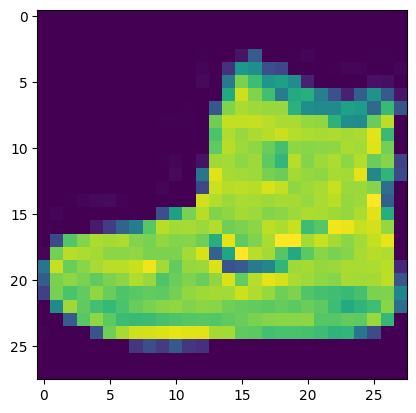

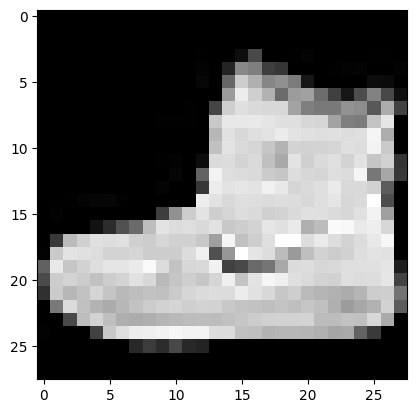

In [ ]:
from matplotlib import pyplot as plt

img,label = train_data[0]


plt.figure()
plt.imshow(img.squeeze())

# to show in the grayscale version:
plt.figure()
plt.imshow(img.squeeze(),cmap="gray")


<Figure size 640x480 with 0 Axes>

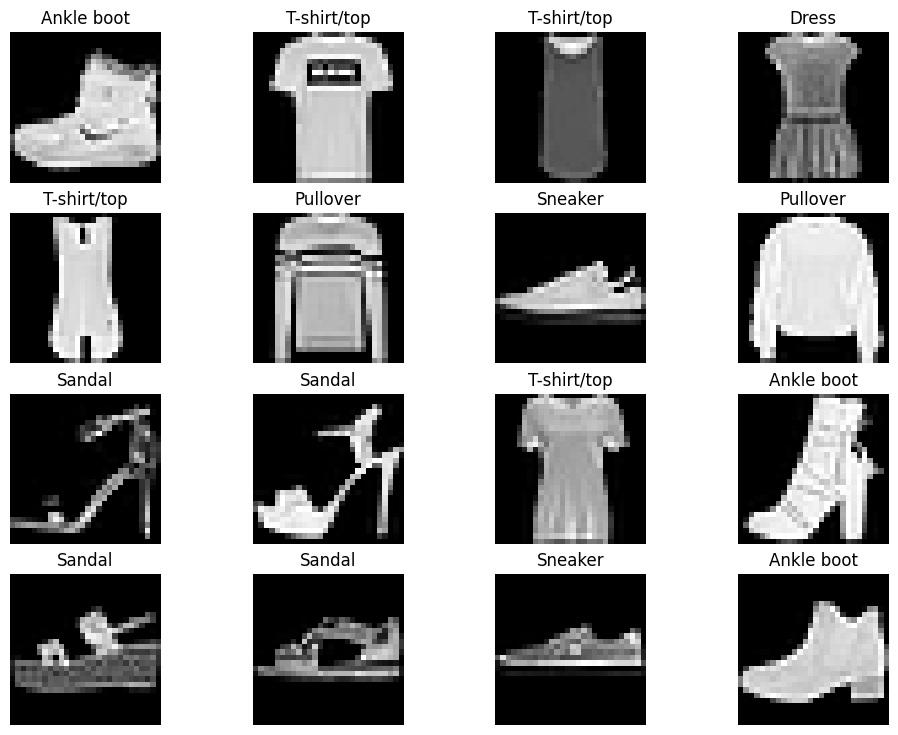

In [ ]:
rows = 4
cols = 4

plt.figure()
fig,axes = plt.subplots(rows,cols,figsize=(12,9))
count = 0
for r in range(0, rows):
  for c in range(0,cols):
    img,label = train_data[count]
    axes[r][c].imshow(img.squeeze(),cmap="gray")
    axes[r][c].set_title(class_names[label])
    axes[r][c].axis("off")
    count = count + 1


# Prep the Dataloader

as discussed above the actual data is in the disk and not in a list format.
So to use the data for training, the `torch.utils.data.DataLoader`  class is used to load the data from the disk. It turns a huge datasets into small batches of desired sizes.

For huge datasets, batching is more computationally efficient

In [ ]:
from torch.utils.data import DataLoader

Batch_size = 32

train_dataloader = DataLoader(train_data,batch_size=Batch_size,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=Batch_size,shuffle=True)

print(f"train_dataloader  consists of {len(train_dataloader)} batches each of size {Batch_size}")
print(f"test_dataloader  consists of {len(test_dataloader)} batches each of size {Batch_size}")

# the dataloader returns an iterable of the batches
img_batch,label_batch = next(iter(train_dataloader))
print("image batch and class batch shapes:")
print(img_batch.shape,label_batch.shape)

train_dataloader  consists of 1875 batches each of size 32
test_dataloader  consists of 313 batches each of size 32
image batch and class batch shapes:
torch.Size([32, 1, 28, 28]) torch.Size([32])


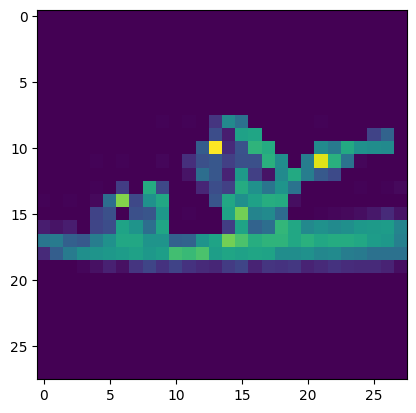

In [ ]:
plt.imshow(img_batch[25].squeeze())

# Base Model

## Flattening images

Since we are working with image data , the images must be flattened since the network does not need a 2D tensor describing the image, it needs a long vector which represents the pixel values

Hence the model will include a Flatten layer, the demo is shown below

NOTE: by default Flatten will flatten the tensor from dimension 1, the dimension 0(batch size in ost cases) will remain intact

In [ ]:
from torch import nn

flatten_model = nn.Flatten()
x = img_batch[0]
output = flatten_model(x)
print(f"shape of image before flattening {x.shape}\nshape of image after flatteing: {output.shape}")

shape of image before flattening torch.Size([1, 28, 28])
shape of image after flatteing: torch.Size([1, 784])


## A linear model

In [ ]:
class FashionMNISTModel0(nn.Module):
  def __init__(self,in_units:int,out_units:int,hid_units:int):
    super().__init__()
    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_units,out_features=hid_units),
        nn.Linear(in_features=hid_units,out_features=out_units)
    )

  def forward(self,x):
    return self.network(x)

model0 = FashionMNISTModel0(
    in_units=784, # 28x28 img
    out_units=len(class_names),
    hid_units=10
)
model0

FashionMNISTModel0(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
from timeit import default_timer as timer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model0.parameters(),lr=0.1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc
epochs = 3

train_time_start = timer()

for epoch in range(epochs):

  print(f"epoch: {epoch}")
  train_loss = 0
  for batchNum,batch in enumerate(train_dataloader):
    model0.train()
    x,y = batch
    y_preds = model0(x) # shape will be [32,10] since the shape of x is [32,1,28,28] so Flatten will start from the 1st dimension
    loss = loss_fn(y_preds,y)
    train_loss = train_loss + loss # the average of loss over the individual samples in the batch is added up
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batchNum%400 == 0:
      print(f"looked at {batchNum*len(x)} out of {len(train_data)}")

  train_loss = train_loss/len(train_dataloader) # calculate the average loss over all the batches

  model0.eval()

  test_loss = 0
  test_acc = 0
  with torch.inference_mode():
    for batchNum,batch in enumerate(test_dataloader):
      model0.eval()
      x_test,y_test = batch
      test_preds = model0(x_test)
      test_loss = test_loss +  loss_fn(test_preds,y_test)
      test_acc = test_acc + accuracy_fn(y_true=y_test,y_pred=torch.argmax(test_preds,dim=1))

  test_loss = test_loss/len(test_dataloader)
  test_acc = test_acc/len(test_dataloader)
  print(f"train loss is {train_loss} | test loss is {test_loss} | test accuray is {test_acc}")

train_time_end = timer()

print(f"took {train_time_end-train_time_start} seconds to train model on cpu")


epoch: 0
looked at 0 out of 60000
looked at 12800 out of 60000
looked at 25600 out of 60000
looked at 38400 out of 60000
looked at 51200 out of 60000
train loss is 0.5942966938018799 | test loss is 0.5247609615325928 | test accuray is 82.12859424920129
epoch: 1
looked at 0 out of 60000
looked at 12800 out of 60000
looked at 25600 out of 60000
looked at 38400 out of 60000
looked at 51200 out of 60000
train loss is 0.4777820110321045 | test loss is 0.49238312244415283 | test accuray is 82.13857827476038
epoch: 2
looked at 0 out of 60000
looked at 12800 out of 60000
looked at 25600 out of 60000
looked at 38400 out of 60000
looked at 51200 out of 60000
train loss is 0.4558084011077881 | test loss is 0.4875735342502594 | test accuray is 82.32827476038338
took 28.230848898999966 seconds to train model on cpu


### Setting up a model Eval function and loop functions


since multiple models are going to be tested , it will do good to create a wrapper function which runs all the training and returns the result for different models

In [ ]:
def eval_model(
    model:torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device,
):
  loss,acc = 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x = x.to(device)
      y = y.to(device)
      y_preds = model(x)
      loss = loss + loss_fn(y_preds,y)
      acc = acc + accuracy_fn(y_true=y,y_pred= torch.argmax(y_preds,dim=1))
  loss = loss/len(data_loader)
  acc = acc/len(data_loader)

  return {
            "model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc
  }

model0_results = eval_model(
    model=model0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device = "cpu"
)

model0_results

{'model_name': 'FashionMNISTModel0',
 'model_loss': 0.48807305097579956,
 'model_acc': 82.30830670926518}

## A non-linear model

In [ ]:
from torch.nn.modules.activation import ReLU
from torch.nn.modules.linear import Linear
class FashionMNISTModel1(nn.Module):
  def __init__(self,in_units:int,out_units:int,hid_units:int):
    super().__init__()
    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_units,out_features=hid_units),
        nn.ReLU(),
        nn.Linear(in_features=hid_units,out_features=hid_units),
        nn.ReLU(),
        nn.Linear(in_features=hid_units,out_features=out_units)
    )


  def forward(self,x):
    return self.network(x)


model1 = FashionMNISTModel1(
        in_units=784, # 28x28 img
        out_units=len(class_names),
        hid_units=10
)
model1

FashionMNISTModel1(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
    (5): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model1.parameters(),lr=0.1)

device = "cuda" if torch.cuda.is_available else "cpu"

### setting up training and testing functions

In [ ]:
def train_step(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    optimizer:torch.optim.Optimizer,
    accuracy_fn,
    device:torch.device = device
):
  train_loss,train_acc = 0,0
  model.to(device)

  for batch,(x,y) in enumerate(data_loader):
    x = x.to(device)
    y = y.to(device)
    y_preds = model(x)
    loss = loss_fn(y_preds,y)
    train_loss = train_loss + loss
    acc = accuracy_fn(y_true=y,y_pred=torch.argmax(y_preds,dim=1))
    train_acc = train_acc + acc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss = train_loss/len(data_loader)
  train_acc = train_acc/len(data_loader)

  print(f"train loss: {train_loss:.5f}, train accuracy: {train_acc:.5f}")


def test_step(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    accuracy_fn,
    device:torch.device = device
):
  test_acc,test_loss = 0,0
  model.to(device)

  with torch.inference_mode():
    for batch,(x,y) in enumerate(data_loader):
      x = x.to(device)
      y = y.to(device)
      y_preds = model(x)
      loss = loss_fn(y_preds,y)
      test_loss = test_loss + loss
      acc = accuracy_fn(y_true=y,y_pred=torch.argmax(y_preds,dim=1))
      test_acc = test_acc + acc


    test_loss = test_loss/len(data_loader)
    test_acc = test_acc/len(data_loader)

    print(f"test loss: {test_loss:.5f}, test accuracy: {test_acc:.5f}")

In [ ]:
from timeit import default_timer as timer
epochs = 3
start_time = timer()

for epoch in range(epochs):
  print(f"epoch {epoch} :")
  train_step(
      model=model1,
      data_loader=train_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      accuracy_fn=accuracy_fn,
      device=device
  )
  test_step(
      model=model1,
      data_loader=train_dataloader,
      loss_fn=loss_fn,
      accuracy_fn=accuracy_fn,
      device=device
  )

end_time = timer()

print(f"took {end_time - start_time} seconds to train model on gpu")

model1_results = eval_model(
    model=model1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device = device
)
model1_results

epoch 0 :
train loss: 0.76242, train accuracy: 72.24000
test loss: 0.56845, test accuracy: 79.90333
epoch 1 :
train loss: 0.51916, train accuracy: 81.66333
test loss: 0.47470, test accuracy: 83.02167
epoch 2 :
train loss: 0.47603, train accuracy: 83.01000
test loss: 0.43886, test accuracy: 84.37667
took 50.035837644000026 seconds to train model on gpu


{'model_name': 'FashionMNISTModel1',
 'model_loss': 0.4921039342880249,
 'model_acc': 82.84744408945687}

In [ ]:
print(model1_results)
print(model0_results)

{'model_name': 'FashionMNISTModel1', 'model_loss': 0.4921039342880249, 'model_acc': 82.84744408945687}
{'model_name': 'FashionMNISTModel0', 'model_loss': 0.48807305097579956, 'model_acc': 82.30830670926518}


## Insights

there are two main focuses of the above two model results

1. **Time**: the time taken to complete the training is more or less equal in both cpu based linear model and non-linear gpu based model if not better in cpu based model.
The reason for this is that moving a tensor across devices is an expensive operation and  the time spent on that transfer is more than the time saved during processing of the tensors

2. **Accuracy and loss**: the results of both the models are very similar (83~85%) accuracy for both the models. This is due to the
fact that the FashionMnist dataset contains good enough average pixel signatures that even a linear model can achieve hight enough accuracy.
To make the most out of non-linear model a *CNN* should be implemented

# CNNs

let's try to work around this problem using a CNN
info about CNNs is covered here [this notebook](https://github.com/Aayush974/learning-pytorch/blob/main/Cnns.ipynb) covers the Cnns theory

In [ ]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
images = torch.randn(size=(32,3,62,62))

test_image = images[0]
print(test_image.shape)
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here

# Pass the data through the convolutional layer
conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input)

torch.Size([3, 62, 62])


tensor([[[ 4.1322e-01, -2.4382e-01, -9.3838e-01,  ...,  6.3278e-02,
           3.4737e-01, -1.2026e-02],
         [ 7.3382e-01,  2.6961e-01,  5.3243e-01,  ..., -4.6156e-01,
          -2.1386e-01, -4.4351e-01],
         [ 4.6714e-01,  8.3728e-01, -3.2383e-01,  ...,  2.9814e-01,
          -5.0236e-01,  9.2514e-01],
         ...,
         [ 5.7950e-01,  9.8298e-01, -7.5891e-01,  ...,  5.0600e-01,
           3.5840e-01, -1.1663e-01],
         [-2.2467e-01, -5.2561e-01,  7.4650e-02,  ...,  5.3119e-01,
           4.7289e-01,  1.6882e-01],
         [-3.1303e-01,  2.1966e-01, -5.3342e-01,  ...,  1.1401e+00,
           4.7787e-01, -4.8883e-01]],

        [[ 5.0932e-01,  1.2351e-01, -1.0257e+00,  ..., -1.4917e+00,
           2.3867e-01, -5.1309e-01],
         [-1.3428e-01,  4.5534e-01,  3.2128e-01,  ...,  7.3077e-01,
          -3.0756e-01, -9.3877e-02],
         [ 8.8557e-02,  4.7486e-01, -1.5777e+00,  ..., -6.1150e-02,
          -1.6898e+00, -8.2737e-02],
         ...,
         [ 2.9023e-01,  9

In [ ]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3
for epoch in range(epochs):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
print(f"time taken be cnn model:{train_time_end_model_2-train_time_start_model_2}")

Epoch: 0
---------
train loss: 0.60085, train accuracy: 78.18500
test loss: 0.41192, test accuracy: 85.31350
Epoch: 1
---------
train loss: 0.35823, train accuracy: 86.98167
test loss: 0.38390, test accuracy: 86.44169
Epoch: 2
---------
train loss: 0.32068, train accuracy: 88.48667
test loss: 0.33984, test accuracy: 87.60982
time taken be cnn model:37.79141271399999


In [ ]:
# Get model_2 results
model2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
print(model1_results)
print(model0_results)
print(model2_results)

{'model_name': 'FashionMNISTModel1', 'model_loss': 0.4921039342880249, 'model_acc': 82.84744408945687}
{'model_name': 'FashionMNISTModel0', 'model_loss': 0.48807305097579956, 'model_acc': 82.30830670926518}
{'model_name': 'FashionMNISTModelV2', 'model_loss': 0.339438796043396, 'model_acc': 87.62979233226837}


as evident the CNN model have 5% higher accuracy than the other 2 models